In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, KFold

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [2]:
df = pd.read_excel("aerial_distance_moscow_vs_gdp_military_spend.xlsx")

df.head()

,country,capital,aerial_distance_moscow,2022,2023,2024,2025,Average
0,Lithuania,Vilnius,790.41,0.025587,0.028363,0.031445,0.030798,0.029048
1,Latvia,Riga,841.57,0.022546,0.029333,0.032979,0.036077,0.030234
2,Estonia,Tallinn,866.96,0.021432,0.029828,0.033026,0.033744,0.029507
3,Finland,Helsinki,892.29,0.015896,0.020089,0.021771,0.025712,0.020867
4,Poland,Warsaw,1150.70,0.022046,0.032567,0.037547,0.044969,0.034282


In [3]:
X = df[["aerial_distance_moscow"]]

# Target
y = df["Average"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# We create and fit the linear regression model.

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = model.predict(X_test)

In [7]:
print("Intercept:", model.intercept_)
print(f"Slope: {model.coef_[0]:.10f}")
print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print(f"MSE: {mean_squared_error(y_test, y_pred):.10f}")

# Pearson Correlation Coefficient
r = df["aerial_distance_moscow"].corr(df["Average"])

print("Pearson Correlation Coefficient:", r)
#print("R-squared:", model.score(X_test, y_test))

Intercept: 0.02866172116730438
Slope: -0.0000043420
R-squared: -0.12679408387837965
RMSE: 0.0070338967744175375
MSE: 0.0000494757
Pearson Correlation Coefficient: -0.5970709083071045


Average Yearly Military Expenditure (% of GDP) = Intercept + Slope * aerial_distance_moscow

>For every single kilometer that a European NATO member gets further from Moscow, we see a 0.00056% decrease in Average Yearly Military Expenditure (% of GDP).

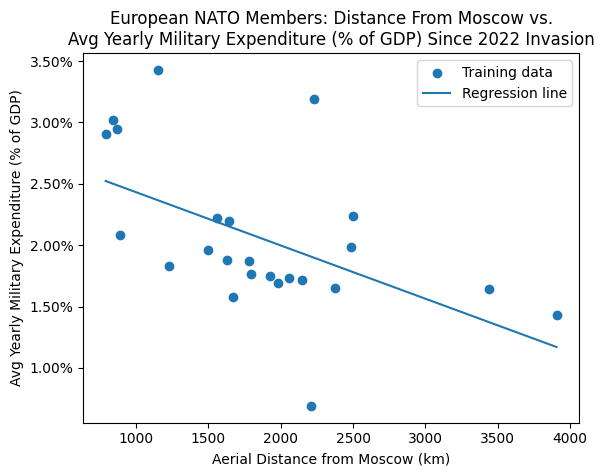

In [8]:
# Plotting the Linear Regression Model

x_line = pd.DataFrame({
    "aerial_distance_moscow": np.linspace(
        X["aerial_distance_moscow"].min(),
        X["aerial_distance_moscow"].max(),
        100
    )
})

y_line = model.predict(x_line)

plt.scatter(X_train, y_train, label="Training data")
#plt.scatter(X_test, y_test, label="Test data")
plt.plot(x_line["aerial_distance_moscow"], y_line, label="Regression line")
plt.xlabel("Aerial Distance from Moscow (km)")
plt.ylabel("Avg Yearly Military Expenditure (% of GDP)")
plt.title("European NATO Members: Distance From Moscow vs.\n"
          "Avg Yearly Military Expenditure (% of GDP) Since 2022 Invasion")

plt.legend()
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.show()

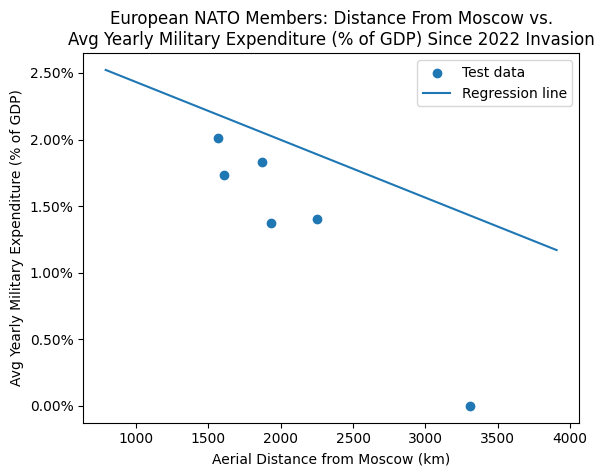

In [9]:
# Plotting the test data

x_line = pd.DataFrame({
    "aerial_distance_moscow": np.linspace(
        X["aerial_distance_moscow"].min(),
        X["aerial_distance_moscow"].max(),
        100
    )
})

y_line = model.predict(x_line)

#plt.scatter(X_train, y_train, label="Training data")
plt.scatter(X_test, y_test, label="Test data")
plt.plot(x_line["aerial_distance_moscow"], y_line, label="Regression line")
plt.xlabel("Aerial Distance from Moscow (km)")
plt.ylabel("Avg Yearly Military Expenditure (% of GDP)")
plt.title("European NATO Members: Distance From Moscow vs.\n"
          "Avg Yearly Military Expenditure (% of GDP) Since 2022 Invasion")

plt.legend()
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.show()

In [10]:
print(y_test)

27    0.000000
15    0.018327
23    0.014061
17    0.013746
8     0.020112
9     0.017366
Name: Average, dtype: float64


In [11]:
print(y_pred)

[0.0142999  0.02055394 0.01887917 0.02027249 0.02184843 0.02167613]


In [12]:
# We'll actually try making a prediction based on 1700 km from Moscow for
# an imaginary NATO member.

imagine_distance = pd.DataFrame({
    "aerial_distance_moscow": [1600]
})

prediction = model.predict(imagine_distance)

print(prediction)

[0.02171447]
